# 7주차 3교시 — 실데이터로 하는 금융 데이터 시각화 (Python)

이번 실습은 **실제 주식 데이터**(`clean_finance.csv`)를 사용합니다.

- 대상: 초급~초중급
- 목표: **데이터를 읽고 → 필요한 지표를 만들고 → 목적에 맞는 차트를 그려서** 인사이트를 말로 정리하기

---

## 오늘 실습 로드맵(중요)

1. 데이터 불러오기 (CSV)
2. 데이터 정리 (날짜/정렬/결측치)
3. 파생변수 만들기 (수익률, 누적수익률, 이동평균)
4. 목적별 차트 구현
   - 비교(Comparison)
   - 분포(Distribution)
   - 구성(Composition)
   - 관계(Relationship)

---

## 데이터 설명

이 데이터는 **하루를 7개 값으로 요약**합니다.

- `date`: 날짜
- `ticker`: 종목 코드
- `open`: 시가(그날 시작 가격)
- `high`: 고가(그날 가장 비싼 가격)
- `low`: 저가(그날 가장 싼 가격)
- `close`: 종가(그날 마지막 가격) — 오늘 실습의 중심
- `volume`: 거래량(거래된 주식 수)

> 용어 요약: **OHLCV = Open/High/Low/Close/Volume**


## 0. 환경 준비

필요 라이브러리:
- pandas, numpy: 데이터 처리
- matplotlib: 그래프 기본 엔진
- seaborn: 예쁜 기본 스타일 + 통계 그래프

> 팁: Seaborn도 내부적으로 Matplotlib을 사용합니다.


In [2]:
# 설치가 필요하면 주석을 풀고 실행하세요.
# !pip -q install pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,119 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

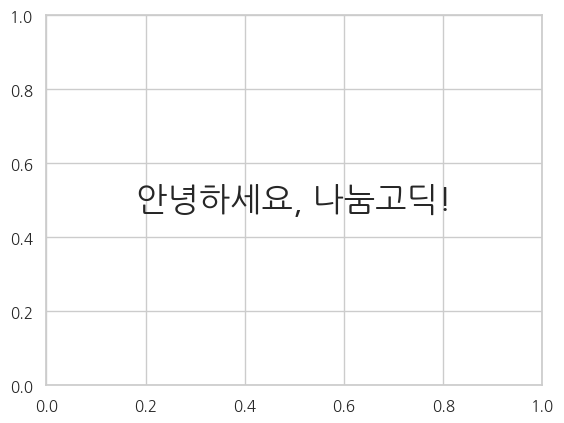

In [3]:
# 시각화 설정
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get install -y fonts-nanum
!fc-cache -fv
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.text(0.5, 0.5, '안녕하세요, 나눔고딕!', ha='center', va='center', size=24)
plt.show()

import seaborn as sns
from matplotlib import rc

sns.set(style="whitegrid")

# 한글 폰트 설정
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 불러오기

우리는 원본(5년·500종목)을 그대로 쓰지 않고, 수업용으로 가볍게 만든 파일을 씁니다.

- 파일명: `clean_finance.csv`
- 특징: 2년치, 6개 종목만 포함

> 파일이 같은 폴더에 있어야 합니다.


In [4]:
df = pd.read_csv("/content/drive/MyDrive/clean_finance.csv")

# 날짜를 날짜 타입으로 바꾸기(중요)
df["date"] = pd.to_datetime(df["date"])

# 정렬(중요): 종목별로 날짜 순서가 맞아야 수익률 계산이 정확합니다.
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

df.head()

,date,ticker,open,high,low,close,volume
0,2016-02-08,A,35.61,35.78,34.390,34.80,3888601
1,2016-02-09,A,34.21,35.77,34.150,35.37,3464464
2,2016-02-10,A,35.63,36.73,35.530,35.85,3169951
3,2016-02-11,A,35.12,35.61,34.935,35.33,3224004
4,2016-02-12,A,35.84,36.23,35.520,36.22,3923627


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3030 non-null   datetime64[ns]
 1   ticker  3030 non-null   object        
 2   open    3030 non-null   float64       
 3   high    3030 non-null   float64       
 4   low     3030 non-null   float64       
 5   close   3030 non-null   float64       
 6   volume  3030 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 165.8+ KB


### 1-1) 빠른 점검

- 종목 수가 6개인지
- 날짜 범위가 2년인지
- 결측치가 있는지


In [6]:
print("tickers:", df["ticker"].nunique())
print("date min:", df["date"].min())
print("date max:", df["date"].max())

df.isna().sum()

tickers: 6
date min: 2016-02-08 00:00:00
date max: 2018-02-07 00:00:00


,0
date,0
ticker,0
open,0
high,0
low,0
close,0
volume,0


## 2. 파생변수 만들기(오늘의 핵심)

### 2-1) 수익률(Return)

- 가격 자체는 종목마다 단위가 달라 비교가 어렵습니다.
- 그래서 **수익률(%)**로 바꿔서 비교합니다.

수익률 정의(아주 쉬운 버전):
- `Return = (오늘 close / 어제 close) - 1`

### 2-2) 누적수익률(Cumulative Return)

- 첫 날을 1로 두고, 시간이 지날수록 얼마나 불었는지 보는 지표


In [7]:
df_feat = df.copy()

# 일간 수익률(종목별)
df_feat["return"] = df_feat.groupby("ticker")["close"].pct_change()

# 누적수익률: 첫 날 수익률 NaN은 0으로 보고 시작하면 1부터 시작합니다.
df_feat["return_fill0"] = df_feat["return"].fillna(0)
df_feat["cum_return"] = df_feat.groupby("ticker")["return_fill0"].transform(lambda s: (1 + s).cumprod())

# 이동평균(추세를 부드럽게)
df_feat["ma20"] = df_feat.groupby("ticker")["close"].transform(lambda s: s.rolling(20).mean())

df_feat.head()

,date,ticker,open,high,low,close,volume,return,return_fill0,cum_return,ma20
0,2016-02-08,A,35.61,35.78,34.390,34.80,3888601,NaN,0.000000,1.000000,NaN
1,2016-02-09,A,34.21,35.77,34.150,35.37,3464464,0.016379,0.016379,1.016379,NaN
2,2016-02-10,A,35.63,36.73,35.530,35.85,3169951,0.013571,0.013571,1.030172,NaN
3,2016-02-11,A,35.12,35.61,34.935,35.33,3224004,-0.014505,-0.014505,1.015230,NaN
4,2016-02-12,A,35.84,36.23,35.520,36.22,3923627,0.025191,0.025191,1.040805,NaN


## 3. Matplotlib vs Seaborn (아주 짧게)

- Matplotlib: 그래프의 "엔진" (세밀하게 컨트롤 가능)
- Seaborn: Matplotlib 위에 "편의 기능"을 얹은 것 (빠르고 예쁘게)

### 오늘 규칙(초급용)

- 제목(title) 반드시 쓰기
- x축/y축 라벨 쓰기
- 단위(%, 원/달러 등) 의식하기


In [8]:
# 비교를 위해 종목 1개만 먼저 보기
one_ticker = df_feat["ticker"].unique()[0]
one = df_feat[df_feat["ticker"] == one_ticker].copy()

one_ticker, one.head()

('A',
         date ticker   open   high     low  close   volume    return  \
 0 2016-02-08      A  35.61  35.78  34.390  34.80  3888601       NaN   
 1 2016-02-09      A  34.21  35.77  34.150  35.37  3464464  0.016379   
 2 2016-02-10      A  35.63  36.73  35.530  35.85  3169951  0.013571   
 3 2016-02-11      A  35.12  35.61  34.935  35.33  3224004 -0.014505   
 4 2016-02-12      A  35.84  36.23  35.520  36.22  3923627  0.025191   
 
    return_fill0  cum_return  ma20  
 0      0.000000    1.000000   NaN  
 1      0.016379    1.016379   NaN  
 2      0.013571    1.030172   NaN  
 3     -0.014505    1.015230   NaN  
 4      0.025191    1.040805   NaN  )

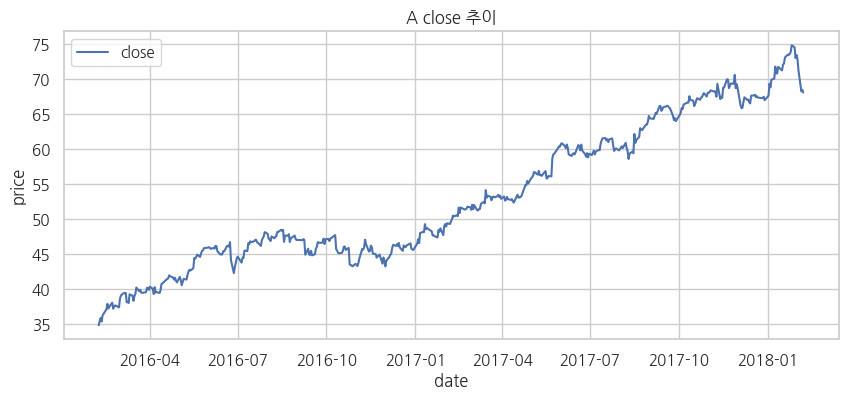

In [9]:
# Matplotlib 기본 라인 플롯
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(one["date"], one["close"], label="close")
ax.set_title(f"{one_ticker} close 추이")
ax.set_xlabel("date")
ax.set_ylabel("price")
ax.legend()
plt.show()

## 4. 목적별 차트 실습(2교시 매트릭스 연결)

우리는 항상 먼저 질문을 정합니다.

- 비교(Comparison): 누가 더 크고/잘했고/증가했나?
- 분포(Distribution): 값이 얼마나 퍼져 있나?
- 구성(Composition): 전체 중 비중이 어떻게 되나?
- 관계(Relationship): 같이 움직이나?


### 4-A) 비교(Comparison)

#### 차트 1) 종목별 close 추이(라인)
질문: "종목별로 가격 흐름이 어떻게 다른가?"


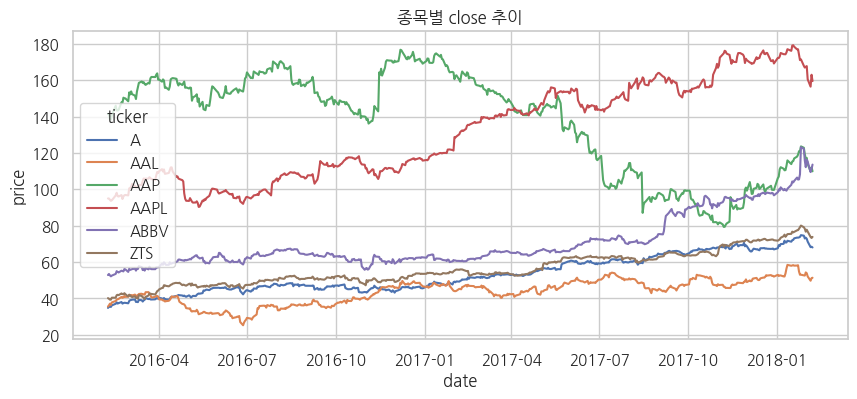

In [10]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_feat, x="date", y="close", hue="ticker")
plt.title("종목별 close 추이")
plt.xlabel("date")
plt.ylabel("price")
plt.show()

#### 차트 2) 종목별 누적수익률 비교
질문: "처음(=1) 대비, 누가 더 잘 갔나?"


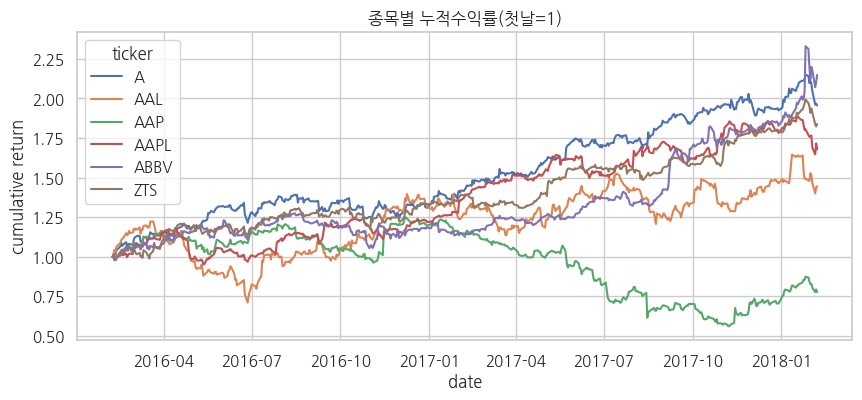

In [11]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=df_feat, x="date", y="cum_return", hue="ticker")
plt.title("종목별 누적수익률(첫날=1)")
plt.xlabel("date")
plt.ylabel("cumulative return")
plt.show()

#### 차트 3) Small Multiples(작은 여러 개 그래프)
질문: "종목별 close + ma20을 한 번에 비교하고 싶다"

> 여기서부터가 초중급 포인트: 한 그래프에 다 그리면 복잡할 때, 작은 그래프 여러 개가 더 명확합니다.


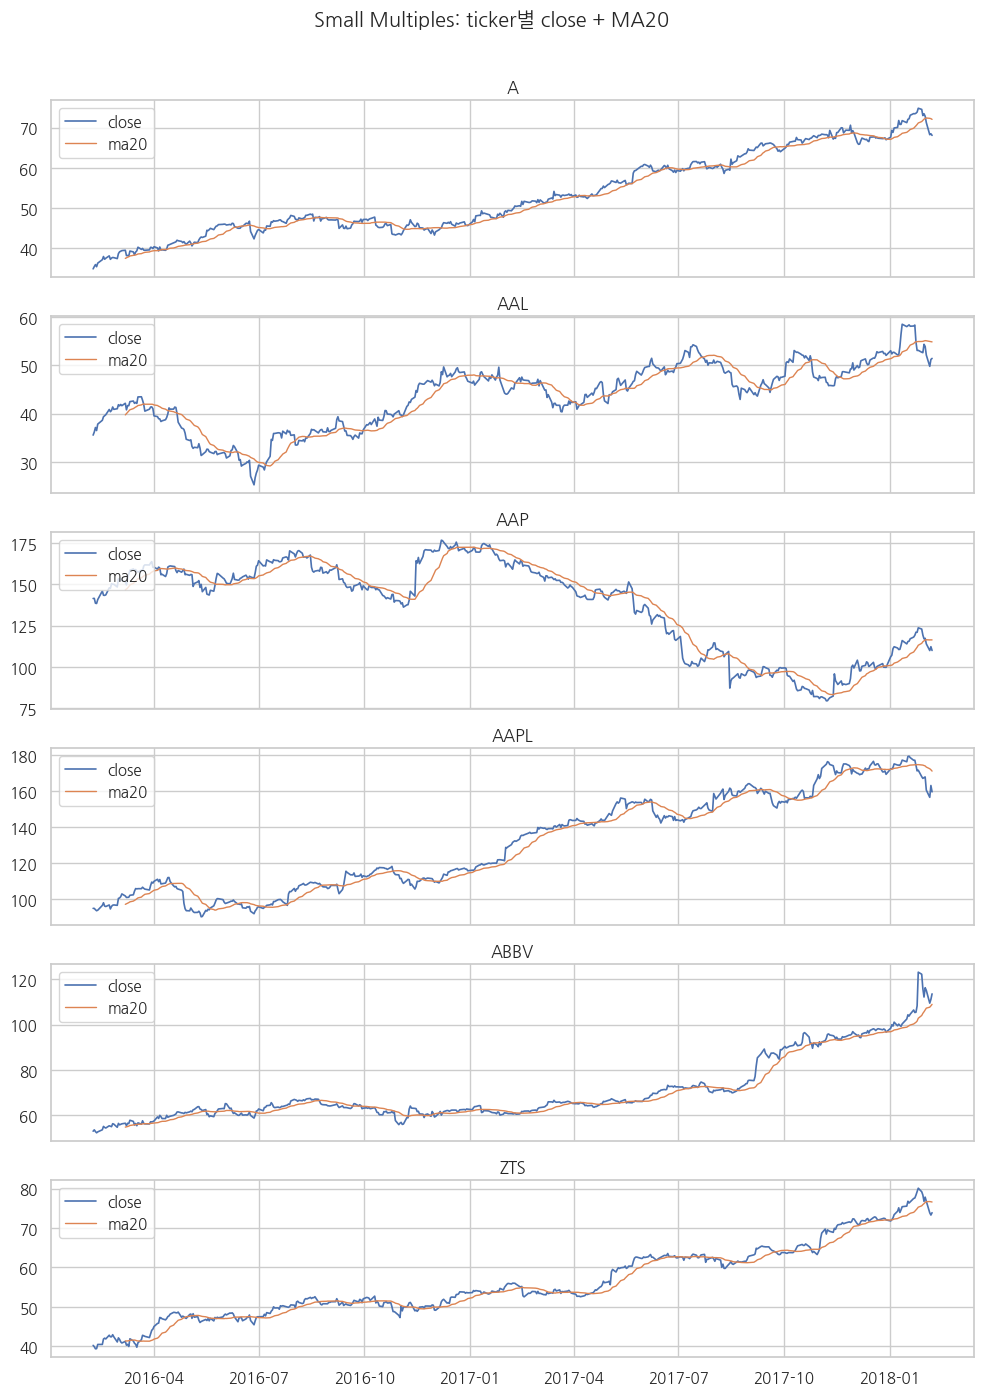

In [12]:
tickers = sorted(df_feat["ticker"].unique())

fig, axes = plt.subplots(nrows=len(tickers), ncols=1, figsize=(10, 2.3*len(tickers)), sharex=True)

for ax, t in zip(axes, tickers):
    d = df_feat[df_feat["ticker"] == t]
    ax.plot(d["date"], d["close"], label="close", linewidth=1.2)
    ax.plot(d["date"], d["ma20"], label="ma20", linewidth=1.0)
    ax.set_title(t)
    ax.legend(loc="upper left")

fig.suptitle("Small Multiples: ticker별 close + MA20", y=1.01)
fig.tight_layout()
plt.show()

### 4-B) 분포(Distribution)

#### 차트 4) 수익률 히스토그램(+KDE)
질문: "수익률은 보통 어느 범위에 많이 몰려있나?"


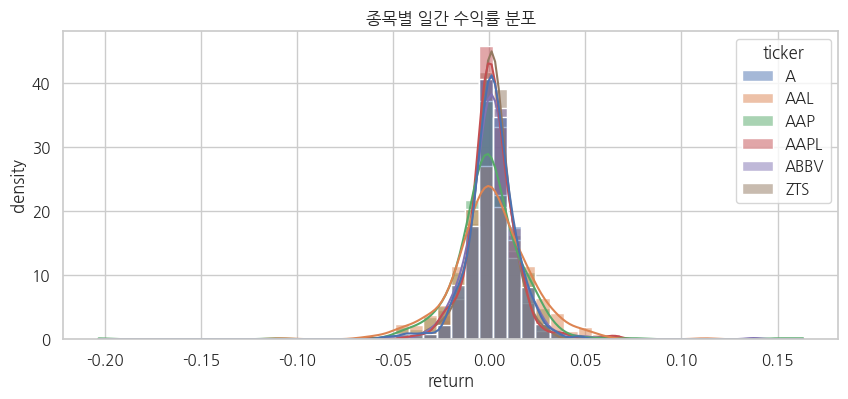

In [13]:
tmp = df_feat.dropna(subset=["return"]).copy()

plt.figure(figsize=(10, 4))
sns.histplot(data=tmp, x="return", hue="ticker", bins=50, kde=True,
             stat="density", common_norm=False)
plt.title("종목별 일간 수익률 분포")
plt.xlabel("return")
plt.ylabel("density")
plt.show()

#### 차트 5) 박스플롯(종목별 수익률 비교)
질문: "누가 더 흔들리고(리스크), 중앙값이 어떤가?"

> 초급 주의: 박스플롯 가운데 선은 '평균'이 아니라 '중앙값'입니다.


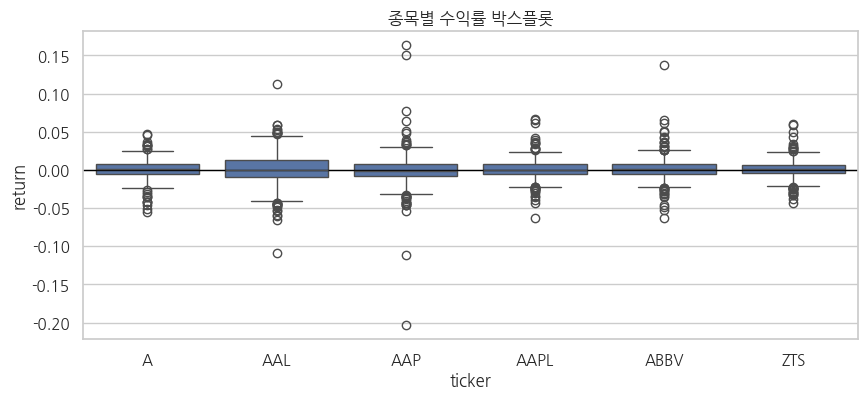

In [14]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=tmp, x="ticker", y="return")
plt.axhline(0, color="black", linewidth=1)
plt.title("종목별 수익률 박스플롯")
plt.xlabel("ticker")
plt.ylabel("return")
plt.show()

### 4-C) 구성(Composition)

#### 차트 6) 거래대금 비중(100% 누적 막대)
질문: "전체 거래대금 중 종목별 비중이 어떻게 되나?"

정의(간단): 거래대금 = close × volume


In [15]:
df_comp = df_feat.copy()
df_comp["dollar_volume"] = df_comp["close"] * df_comp["volume"]

# 기간 전체 합계로 비중 계산
comp = (df_comp.groupby("ticker")["dollar_volume"].sum()
        .sort_values(ascending=False)
        .to_frame("dollar_volume"))
comp["share"] = comp["dollar_volume"] / comp["dollar_volume"].sum()

comp

,dollar_volume,share
ticker,,
AAPL,2.048846e+12,0.768323
ABBV,2.398986e+11,0.089963
AAL,1.518574e+11,0.056947
AAP,8.832526e+10,0.033122
ZTS,8.650865e+10,0.032441
A,5.121133e+10,0.019204


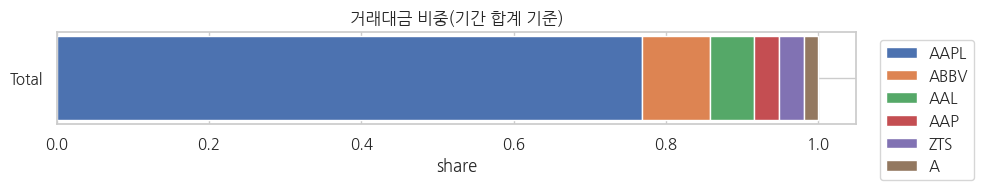

In [16]:
# 100% 누적 막대(종목 비중)
fig, ax = plt.subplots(figsize=(10, 2))
left = 0
for t, row in comp.iterrows():
    ax.barh(["Total"], [row["share"]], left=left, label=t)
    left += row["share"]

ax.set_title("거래대금 비중(기간 합계 기준)")
ax.set_xlabel("share")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4-D) 관계(Relationship)

#### 차트 7) 수익률 상관 히트맵
질문: "종목들이 같이 움직이나?"

> 초급 주의: 상관은 '인과'가 아닙니다.


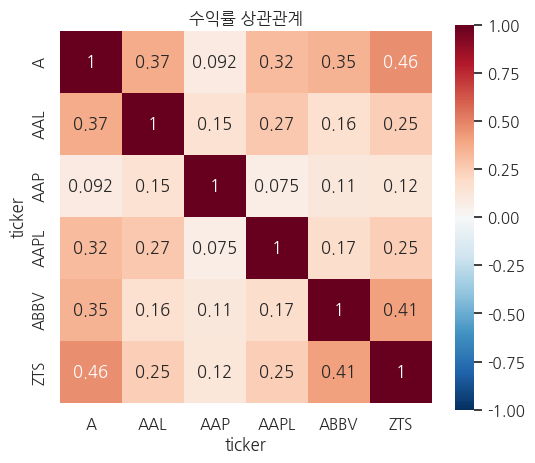

In [17]:
ret_wide = (df_feat.pivot_table(index="date", columns="ticker", values="return")
            .dropna())

corr = ret_wide.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("수익률 상관관계")
plt.show()

#### 차트 8) 리스크-리턴 산점도(초중급 맛보기)
질문: "평균 수익률이 높은 종목은, 변동성도 높은가?"

- x: 변동성(표준편차)
- y: 평균 수익률


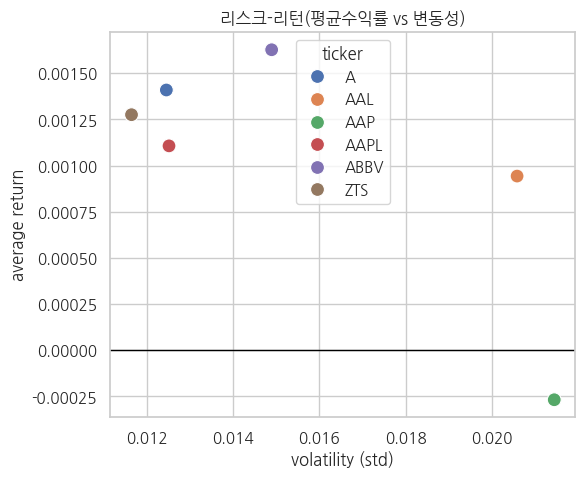

In [18]:
risk_return = (tmp.groupby("ticker")["return"]
               .agg(avg_return="mean", vol="std")
               .reset_index())

plt.figure(figsize=(6, 5))
sns.scatterplot(data=risk_return, x="vol", y="avg_return", hue="ticker", s=100)
plt.axhline(0, color="black", linewidth=1)
plt.title("리스크-리턴(평균수익률 vs 변동성)")
plt.xlabel("volatility (std)")
plt.ylabel("average return")
plt.show()

## 5. (짧게) 나쁜 그래프 → 좋은 그래프

원칙(1교시 복기):
- 명확성: 제목/축/단위
- 정직성: 축 왜곡 금지(특히 Y축)
- 효율성: 불필요한 장식 줄이기

여기서는 '축 라벨이 없는 그래프'를 일부러 만들고, 바로 고쳐보겠습니다.


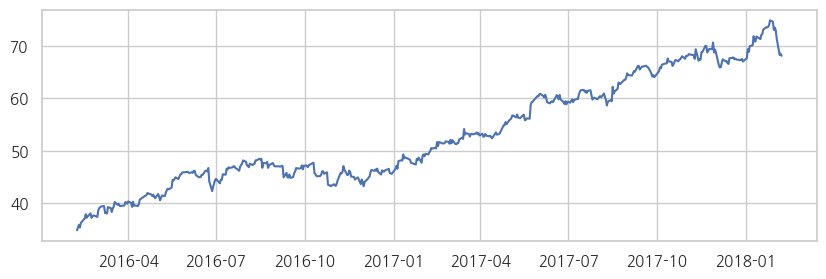

In [19]:
# 나쁜 예시: 제목/축 라벨이 없음
plt.figure(figsize=(10, 3))
plt.plot(one["date"], one["close"])
plt.show()

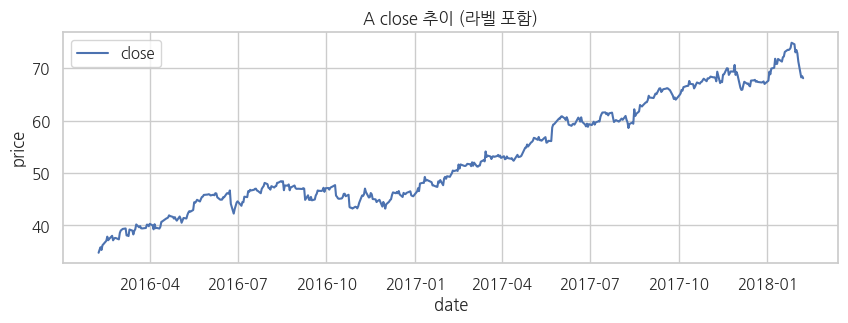

In [20]:
# 좋은 예시: 제목/축/단위/범례를 넣는다
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(one["date"], one["close"], label="close")
ax.set_title(f"{one_ticker} close 추이 (라벨 포함)")
ax.set_xlabel("date")
ax.set_ylabel("price")
ax.legend()
plt.show()